In [ ]:
# Import the Raw data
import pandas as pd

df = pd.read_csv('../data/raw/telco_customer_churn.csv')
print(df.shape)
print(df.dtypes)
df.head()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [2]:
# Convert to numeric — blank/whitespace strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

# Check how many rows broke
print(df['TotalCharges'].isnull().sum())
df[df['TotalCharges'].isnull()]

11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [3]:
# Since it's tenure-0 customers, the sensible fill is 0 (they haven't paid anything yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [4]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [5]:
# removed customerID as it is not a feature 

df.drop('customerID', axis=1, inplace=True)

In [6]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# overall churn rate
churn_rate = df['Churn'].value_counts(normalize= True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# Of the customers who already left, how much money were they paying us every month?

revenue_at_risk = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
print(f"Monthly recurring revenue currently churned: ${revenue_at_risk:,.2f}")

Monthly recurring revenue currently churned: $139,130.85


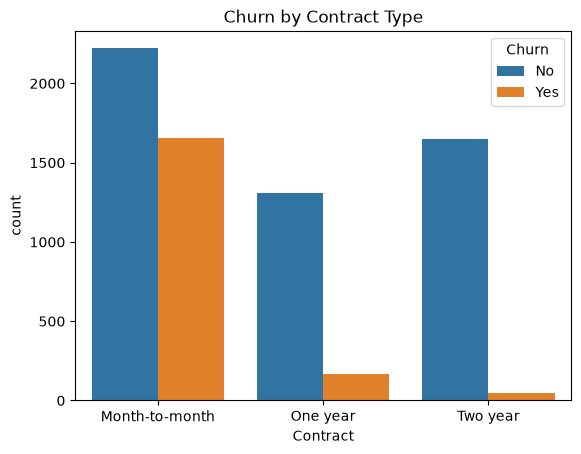

In [ ]:
# Bar chart of Churn by Contract Type(count)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')

plt.savefig('../reports/figures/churn_by_contract_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Churn by Contract Type by %

churn_by_contract = (df.groupby('Contract')['Churn'].value_counts(normalize= True).unstack() * 100 ).round(2)
print(churn_by_contract)

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [ ]:
# How Long Do Customers Stick Around Before Churning?

df.groupby('Churn')['tenure'].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

In [ ]:
# Cohort Analysis: Churn Rate by Tenure Group

df['TenureCohort'] = pd.cut(
    df['tenure'],
    bins = [0,6,12,24,36,48,60,72],
    labels= [
        '0-6 months',
        '7-12 months',
        '13-24 months',
        '25-36 months',
        '37-48 months',
        '49-60 months',
        '61-72 months'
    ],
    right=True, 
    include_lowest=True
)

churn_by_tenure = (
    df.groupby('TenureCohort', observed=True)['Churn']
    .value_counts(normalize= True)
    .unstack()
    .mul(100)
    .round(2)
)

print(churn_by_tenure)

Churn            No    Yes
TenureCohort              
0-6 months    47.06  52.94
7-12 months   64.11  35.89
13-24 months  71.29  28.71
25-36 months  78.37  21.63
37-48 months  80.97  19.03
49-60 months  85.58  14.42
61-72 months  93.39   6.61


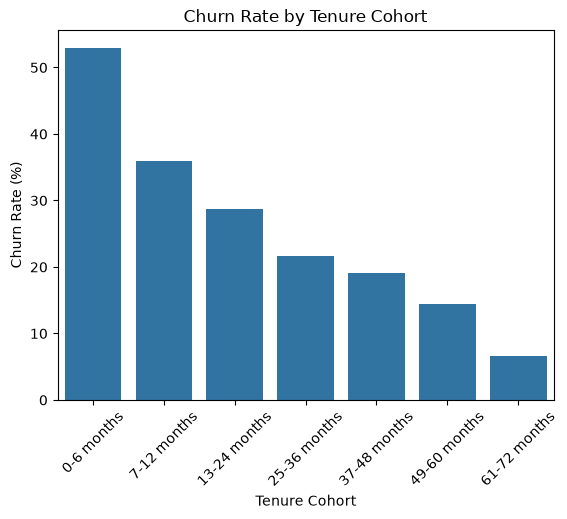

In [ ]:
# Bar chart of Churn Rate by Tenure Cohort

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x=churn_by_tenure.index,
    y=churn_by_tenure['Yes']
)

plt.title('Churn Rate by Tenure Cohort')
plt.xlabel('Tenure Cohort')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

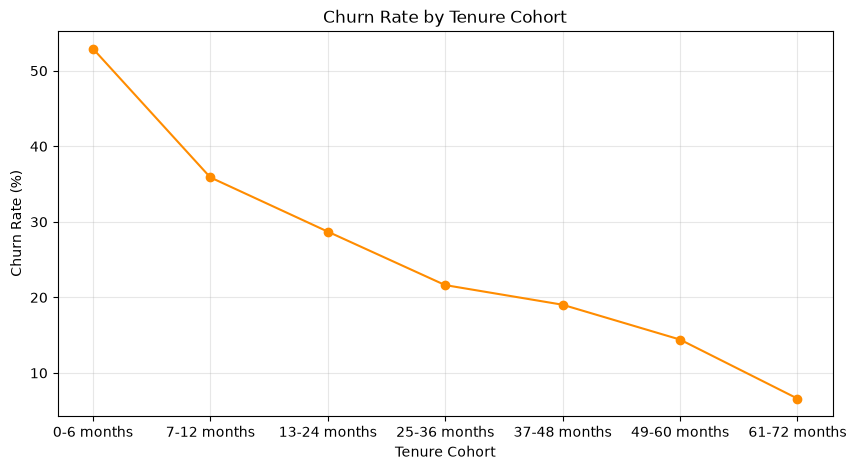

In [ ]:
import matplotlib.pyplot as plt

# the 'Yes' (churned %) column to plot the trend
churn_trend = churn_by_tenure['Yes']

plt.figure(figsize=(10,5))
plt.plot(churn_trend.index, churn_trend.values, marker='o', color='darkorange')
plt.title('Churn Rate by Tenure Cohort')
plt.xlabel('Tenure Cohort')
plt.ylabel('Churn Rate (%)')
plt.grid(alpha=0.3)  # light grid lines, easier to read values
plt.show()

In [ ]:
# Check remaining categorical features against churn

categorical_cols = ['InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print((df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100).round(2))


--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

--- TechSupport ---
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


[0 1]
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66


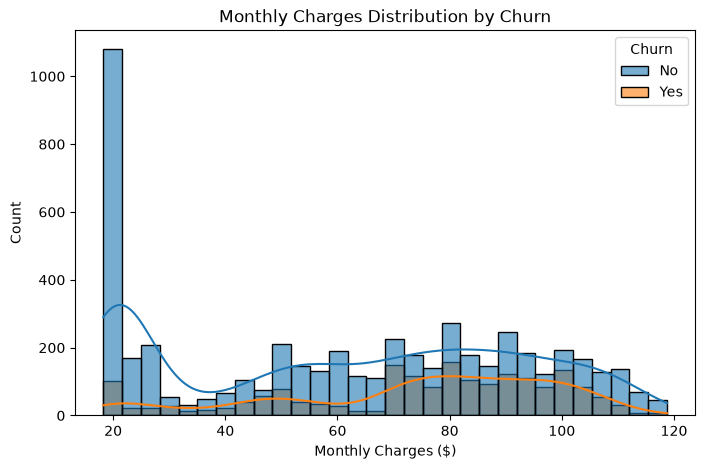

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [9]:
# ============================================================
# SeniorCitizen — is age a churn driver?
# ============================================================
print(df['SeniorCitizen'].unique())

senior_churn = (df.groupby('SeniorCitizen')['Churn']
                 .value_counts(normalize=True)
                 .unstack() * 100).round(2)
print(senior_churn)

# ============================================================
# Dependents — does having dependents affect churn?
# ============================================================
dependents_churn = (df.groupby('Dependents')['Churn']
                     .value_counts(normalize=True)
                     .unstack() * 100).round(2)
print(dependents_churn)

# ============================================================
# Partner — similar idea, household stability angle
# ============================================================
partner_churn = (df.groupby('Partner')['Churn']
                  .value_counts(normalize=True)
                  .unstack() * 100).round(2)
print(partner_churn)

# ============================================================
# MonthlyCharges — distribution, split by churn
# Does the AMOUNT someone pays relate to whether they leave?
# ============================================================
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30, alpha=0.6)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')

plt.savefig('../reports/figures/monthly_charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick numeric summary alongside the chart
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

In [ ]:
# structured summary before EDA overview describe()
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


In [ ]:
# Churn Percentage by Monthly Charges

df['ChargeBand'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 50, 70, 90, 110, 130],
    labels=['0-30', '31-50', '51-70', '71-90', '91-110', '111-130']
)

charge_churn = (
    df.groupby('ChargeBand', observed=True)['Churn']
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .round(2)
)

print(charge_churn)

Churn          No    Yes
ChargeBand              
0-30        90.20   9.80
31-50       69.20  30.80
51-70       79.24  20.76
71-90       62.20  37.80
91-110      64.44  35.56
111-130     86.98  13.02


In [32]:
df['ChargeBand'].value_counts().sort_index()

ChargeBand
0-30       1653
31-50       646
51-70      1161
71-90      1844
91-110     1524
111-130     215
Name: count, dtype: int64

In [45]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/telco_cleaned.csv', index=False)
print("Cleaned data saved.")

Cleaned data saved.
